# World Cup 2026 Predictor - Model Analysis

This notebook analyzes trained models, compares performance, and evaluates feature importance.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PROCESSED_DIR
from src.models.evaluate import evaluate_model, compare_models, plot_calibration_curves
from src.models.train import split_data

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Trained Models

In [2]:
models_dir = PROCESSED_DIR / 'models'
feature_cols = joblib.load(models_dir / 'feature_columns.joblib')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

Feature columns (80): ['elo_home', 'elo_away', 'elo_delta', 'elo_abs_delta', 'elo_home_win_prob', 'elo_draw_prob', 'elo_away_win_prob', 'fifa_rank_home', 'fifa_rank_away', 'fifa_rank_delta', 'fifa_rank_abs_delta', 'fifa_points_home', 'fifa_points_away', 'fifa_points_delta', 'fifa_points_abs_delta', 'neutral', 'home_advantage', 'is_host_nation', 'same_confederation', 'is_world_cup', 'is_qualifier', 'is_friendly', 'is_knockout', 'combined_draw_prob', 'elo_close', 'draw_tendency', 'fifa_close', 'home_form_last10_win_rate', 'home_form_last10_draw_rate', 'home_form_last10_loss_rate', 'home_form_last10_goals_scored_avg', 'home_form_last10_goals_conceded_avg', 'home_form_last10_goal_diff_avg', 'home_form_last10_clean_sheet_rate', 'home_form_last5_win_rate', 'home_form_last5_draw_rate', 'home_form_last5_loss_rate', 'home_form_last5_goals_scored_avg', 'home_form_last5_goals_conceded_avg', 'home_form_last5_goal_diff_avg', 'home_form_last5_clean_sheet_rate', 'away_form_last10_win_rate', 'away_for

In [3]:
models = {}
for model_file in models_dir.glob('*.joblib'):
    if model_file.stem in ('feature_columns', 'best_model', 'imputer'):
        continue
    name = model_file.stem.replace('_', ' ').title()
    models[name] = joblib.load(model_file)
    print(f'Loaded {name}')

best_model = joblib.load(models_dir / 'best_model.joblib')
print(f'\nBest model loaded')

Loaded Randomforest
Loaded Logisticregression
Loaded Xgboost
Loaded Neuralnet

Best model loaded


## 2. Load Features & Split Data

In [4]:
features_path = PROCESSED_DIR / 'match_features.parquet'
df = pd.read_parquet(features_path)
df = df.dropna(subset=['outcome'])

(X_train, y_train, X_val, y_val, X_test, y_test,
 feature_cols, train_df, val_df, test_df) = split_data(df)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

2026-06-15 09:12:00,005 [INFO] worldcup: Splitting data...
2026-06-15 09:12:00,025 [INFO] worldcup: Train: 44837 | Val: 970 | Test: 3606


Train: 44837 | Val: 970 | Test: 3606


## 3. Model Comparison

In [5]:
all_results = {}
for name, model in models.items():
    results = evaluate_model(model, X_test, y_test, name)
    all_results[name] = results

comparison = compare_models(all_results)
comparison

2026-06-15 09:12:00,261 [INFO] worldcup: Evaluating Randomforest...
2026-06-15 09:12:00,444 [INFO] worldcup:   Accuracy: 0.6059
2026-06-15 09:12:00,444 [INFO] worldcup:   Log Loss: 0.8589
2026-06-15 09:12:00,444 [INFO] worldcup:   Brier Scores: {'away_win': 0.14976975871404313, 'draw': 0.1736948943119492, 'home_win': 0.18170256617485944}
2026-06-15 09:12:00,445 [INFO] worldcup: Evaluating Logisticregression...
2026-06-15 09:12:00,451 [INFO] worldcup:   Accuracy: 0.5699
2026-06-15 09:12:00,451 [INFO] worldcup:   Log Loss: 0.8783
2026-06-15 09:12:00,452 [INFO] worldcup:   Brier Scores: {'away_win': 0.1491040140390396, 'draw': 0.17883457243442535, 'home_win': 0.1903287023305893}
2026-06-15 09:12:00,452 [INFO] worldcup: Evaluating Xgboost...
2026-06-15 09:12:00,467 [INFO] worldcup:   Accuracy: 0.5521
2026-06-15 09:12:00,467 [INFO] worldcup:   Log Loss: 0.9183
2026-06-15 09:12:00,467 [INFO] worldcup:   Brier Scores: {'away_win': 0.15893571078777313, 'draw': 0.2012360543012619, 'home_win': 0

,Model,Accuracy,Log Loss,Brier (home_win),Brier (draw),Brier (away_win),Avg Brier
0,Randomforest,0.605935,0.858898,0.181703,0.173695,0.149770,0.168389
1,Logisticregression,0.569884,0.878257,0.190329,0.178835,0.149104,0.172756
2,Xgboost,0.552135,0.918305,0.185707,0.201236,0.158936,0.181960
3,Neuralnet,0.596783,1.171938,0.237030,0.208260,0.159924,0.201738


2026-06-15 09:12:00,550 [INFO] worldcup: Plotting model comparison...


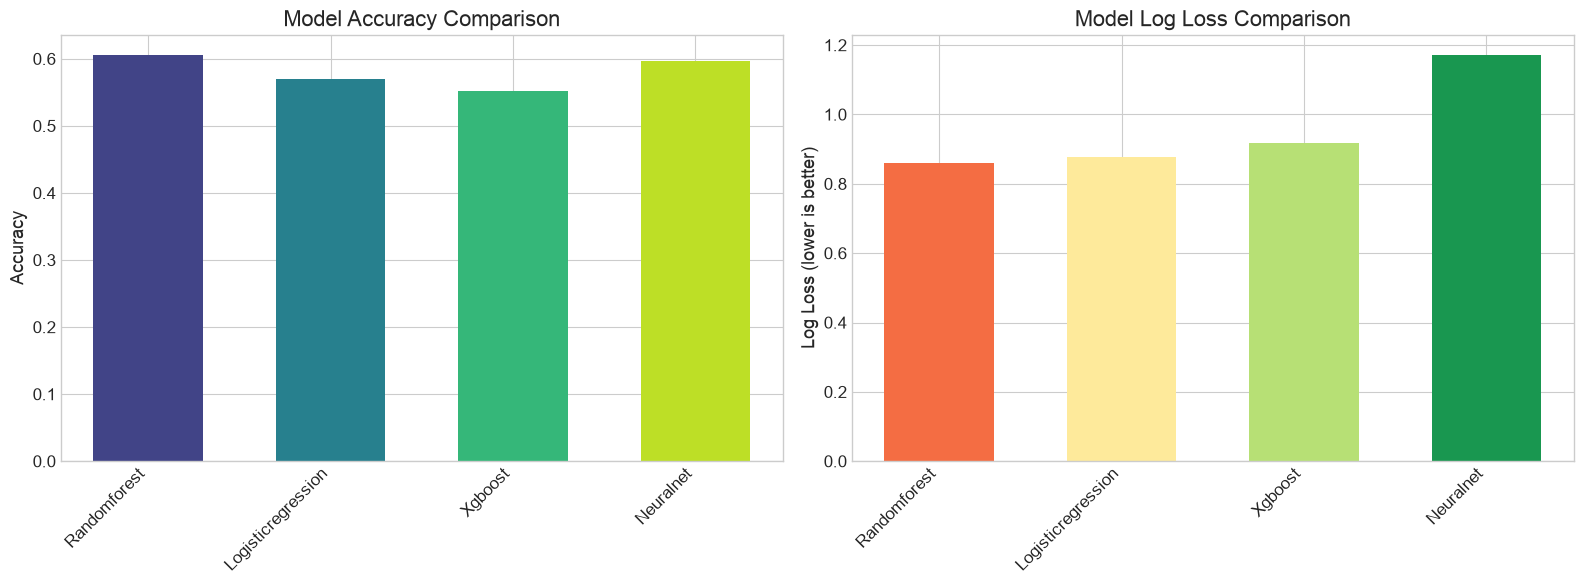

In [6]:
from src.visualization.plots import plot_model_comparison
plot_model_comparison(comparison, save=False)
plt.show()

## 4. Feature Importance

2026-06-15 09:12:00,773 [INFO] worldcup: Plotting feature importance...


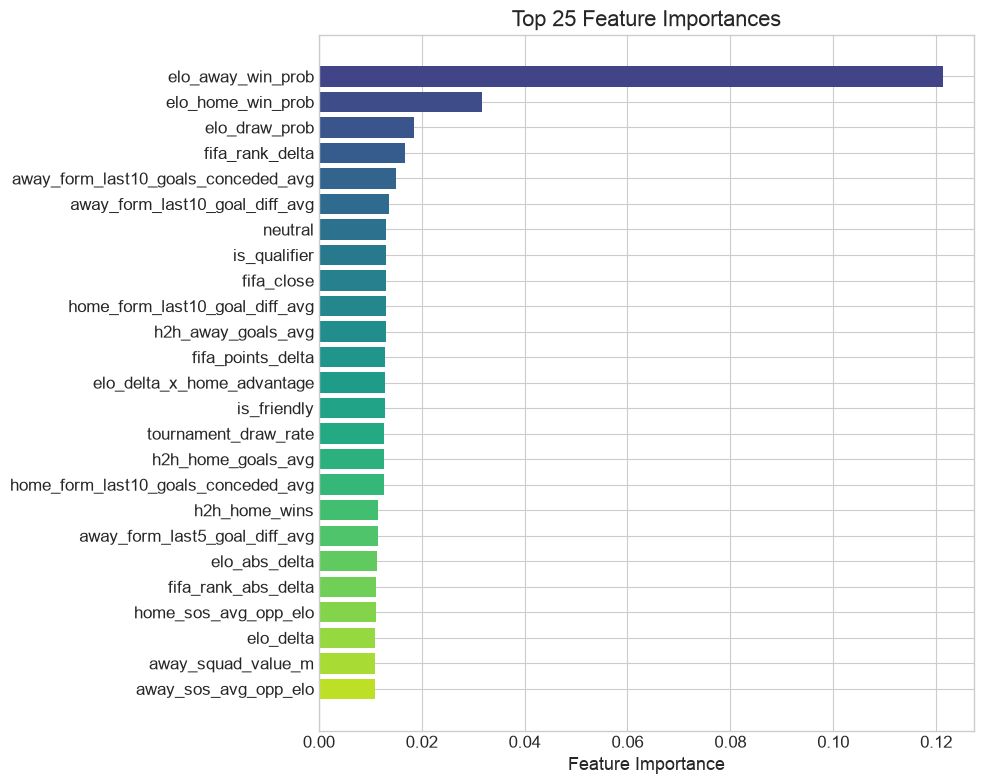

In [7]:
from src.visualization.plots import plot_feature_importance

xgb_key = next((k for k in models if 'xgboost' in k.lower()), None)
if xgb_key:
    plot_feature_importance(models[xgb_key], feature_cols, top_n=25, save=False)
    plt.show()

## 5. Probability Calibration

2026-06-15 09:12:00,992 [INFO] worldcup: Plotting calibration curves...
2026-06-15 09:12:01,208 [INFO] worldcup:   Saved to /Users/sithea/Documents/code/worldcup/data/processed/evaluation/calibration_curves.png


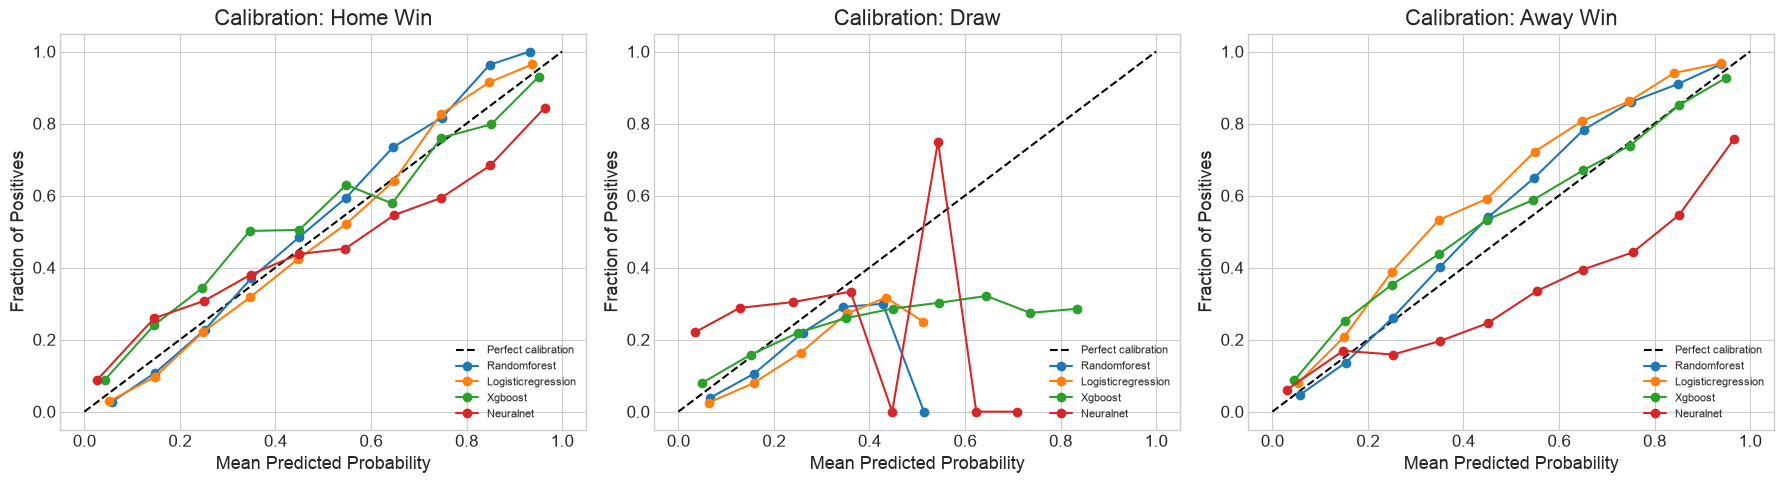

In [8]:
plot_calibration_curves(all_results, X_test, y_test)
plt.show()

## 6. Best Model Details

In [9]:
best_results = evaluate_model(best_model, X_test, y_test, 'Best Ensemble')
print(f'Best model accuracy: {best_results["accuracy"]:.4f}')
print(f'Best model log loss: {best_results["log_loss"]:.4f}')

2026-06-15 09:12:01,321 [INFO] worldcup: Evaluating Best Ensemble...
2026-06-15 09:12:01,426 [INFO] worldcup:   Accuracy: 0.6201
2026-06-15 09:12:01,427 [INFO] worldcup:   Log Loss: 0.8364
2026-06-15 09:12:01,427 [INFO] worldcup:   Brier Scores: {'away_win': 0.14647462010583226, 'draw': 0.16972429946400053, 'home_win': 0.17439262347746132}


Best model accuracy: 0.6201
Best model log loss: 0.8364
